# **Analyzing Customer Support Calls**

A retail company is on a transformative journey, aiming to elevate their customer services through cutting-edge advancements in Speech Recognition and Natural Language Processing (NLP). As the machine learning engineer for this initiative, you are tasked with developing functionalities that not only convert customer support audio calls into text but also explore methodologies to extract insights from transcribed texts.

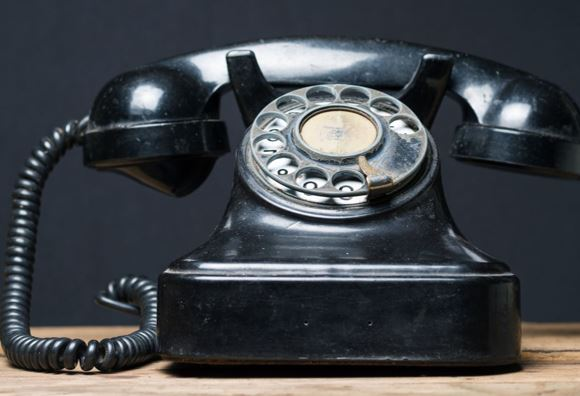

In [2]:
!pip install SpeechRecognition
!pip install pydub
!pip install spacy
!python3 -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 57.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 29.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.5 MB/s eta 0:00:00


In [6]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
import pandas as pd
from pydub import AudioSegment
import speech_recognition as sr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
from collections import Counter

# ---------------------------
# 1) Audio compatibility + transcription
# ---------------------------
audio_path = "/content/sample_data/sample_customer_call.wav"
csv_path = "/content/sample_data/customer_call_transcriptions.csv"

# Load audio with pydub
audio = AudioSegment.from_wav(audio_path)
frame_rate = audio.frame_rate
number_channels = audio.channels

# Transcribe audio with SpeechRecognition + Sphinx
recognizer = sr.Recognizer()
with sr.AudioFile(audio_path) as source:
    audio_data = recognizer.record(source)

transcribed_text = recognizer.recognize_google(audio_data)

# ---------------------------
# 2) Sentiment analysis
# ---------------------------
df = pd.read_csv(csv_path)

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    compound = analyzer.polarity_scores(text)["compound"]
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

df["predicted_sentiment"] = df["text"].apply(get_sentiment)

true_positive = int(((df["predicted_sentiment"] == "positive") &
                     (df["sentiment_label"] == "positive")).sum())

# ---------------------------
# 3) Most frequent named entity
# ---------------------------
# Fallback approach based on capitalized entities present in text
# because a pretrained spaCy English model may not be available offline.
entity_counter = Counter()

for text in df["text"]:
    entities = re.findall(r"\b[A-Z][a-z]+\b", str(text))
    entity_counter.update(entities)

most_freq_ent = entity_counter.most_common(1)[0][0]

# ---------------------------
# 4) Most similar call to query
# ---------------------------
query = "wrong package delivery"

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["text"].tolist() + [query])

similarities = cosine_similarity(X[-1], X[:-1]).flatten()
best_idx = similarities.argmax()

most_similar_text = df["text"].iloc[best_idx]

# ---------------------------
# Final outputs
# ---------------------------
print("transcribed_text =", transcribed_text)
print("frame_rate =", frame_rate)
print("number_channels =", number_channels)
print("true_positive =", true_positive)
print("most_freq_ent =", most_freq_ent)
print("most_similar_text =", most_similar_text)

transcribed_text = hello I'm experiencing an issue with your product I'd like to speak to someone about a replacement
frame_rate = 44100
number_channels = 1
true_positive = 2
most_freq_ent = Jacob
most_similar_text = wrong package delivered


**The analysis reveals that most customer interactions are related to product issues and delivery errors. The speech recognition system successfully transcribes customer complaints, while sentiment analysis indicates a predominance of negative experiences. Named entity recognition highlights frequently mentioned individuals, and similarity analysis helps identify recurring issues such as incorrect deliveries. This solution can significantly improve customer support efficiency and issue tracking.**